# 12. Log-state event decomposition

The primary comparison changes the target from \(X_{t+1}\) to \(\log X_{t+1}\) while retaining the same observable raw predictor basis. It therefore tests a matched-feature log-target formulation rather than every possible model for the conditional log state.

Conceptually, \(F_t=X_t+\alpha\Delta t+\nu\rho\epsilon_t+\text{noise}\) is approximately linear in the original predictors, whereas \(\log F_t=\log(X_t+\alpha\Delta t+\nu\rho\epsilon_t+\text{noise})\) is generally nonlinear. The log transformation makes the event contribution additive, but may make the background baseline harder to estimate with the frozen linear predictor basis. This is conceptual only: no hidden DGP quantity enters estimation.

This one-seed dense-periodic prototype compares the frozen original-state workflow with a log-state formulation. With \(X_{t+1}=\omega_{t+1}^{n/2}F_t\), define \(W_{t+1}=\omega_{t+1}^{n/2}\): \(\log X_{t+1}=\log W_{t+1}+\log F_t\). For this n=1 case, \(\log W_{t+1}=\tfrac12\log\omega_{t+1}\), not \(\log\omega_{t+1}\). Timing remains \(E_t\to\omega_{t+1}\to X_{t+1}\); ages 0–12 map to lags +1–+13.

## Load frozen helpers and construct matched datasets

Notebook 06 supplies the simulator, transition table, original-state pipeline, split, and evaluation conventions. Both formulations use one common shock bank, calendar, split and observable information set. The preflight below checks the actual estimator feature list and the ordered test target identifiers.

In [1]:
RUN_HELPER_SELF_TESTS=False
%run "./06_experiment_workflow_helpers.ipynb"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

LOG_PROTOTYPE_SEED = 20260722
features = ['state_i', 'epsilon_proxy_i']
prohibited_features = {
    'F', 'eta', 'omega_next', 'true_omega', 'alpha', 'nu', 'rho',
    'state_next', 'sigma_next', 'log_state_next',
}

dense_case = make_case_config(
    reference_config,
    label='dense_periodic_n1_log_comparison',
)
shock_bank = make_shock_bank(dense_case, seed=LOG_PROTOTYPE_SEED)
original = run_full_pipeline(
    dense_case,
    shock_bank=shock_bank,
    include_causality=False,
    include_intervals=True,
    include_truth=True,
)
table = original['transition_table']
train = original['split']['train'].copy()
test = original['split']['test'].copy()
timing = original['timing']

for frame in (train, test):
    frame['log_state_next'] = np.log(frame['state_next'])

original_test_target_ids = original['evaluation']['evaluation']['target_i'].to_numpy()
log_test_target_ids = test['target_i'].to_numpy()
event_count = int(original['simulation']['transitions']['event'].sum())
checks = {
    'all X positive': bool(table['state_i'].gt(0).all() and table['state_next'].gt(0).all()),
    'finite log state': bool(np.isfinite(np.log(table[['state_i', 'state_next']])).all().all()),
    'event count matches calendar': event_count == int(table['event_lag_0'].sum()),
    'timing +1 to +13': tuple(timing['event_transition_ages']) == tuple(range(13)),
    'estimator features permitted': set(features).isdisjoint(prohibited_features),
    'same ordered test rows': np.array_equal(original_test_target_ids, log_test_target_ids),
}
preflight = pd.DataFrame([{
    'market-shock seed': LOG_PROTOTYPE_SEED,
    'event count': event_count,
    **checks,
}])
display(preflight)
assert all(checks.values())

Helper self-tests skipped for downstream use.


,market-shock seed,event count,all X positive,finite log state,event count matches calendar,timing +1 to +13,estimator features permitted,same ordered test rows
0,20260722,23,True,True,True,True,True,True


## Fit the log-state baseline and event profiles

The event-free OLS uses exactly the frozen observable predictors, with \(\log X_{t+1}\) as target. Training event residuals estimate the exact log profile \(h_1(a;A,\lambda)=\tfrac12\log(1+A\exp(-\lambda a))\).

In [2]:
active = train['event_active_i'].eq(1)
event_free = ~active
log_baseline = sm.OLS(
    train.loc[event_free, 'log_state_next'],
    sm.add_constant(train.loc[event_free, features], has_constant='add'),
).fit()

def log_base(frame):
    design = sm.add_constant(frame[features], has_constant='add')
    return np.asarray(log_baseline.predict(design))

train['log_F_hat'] = log_base(train)
train['log_residual'] = train['log_state_next'] - train['log_F_hat']
ages = train.loc[active, 'event_age_i'].to_numpy()
residuals = train.loc[active, 'log_residual'].to_numpy()

def h_profile(parameters, age):
    amplitude, decay = parameters
    scaled_age = np.asarray(age) / timing['steps_per_year']
    return 0.5 * np.log1p(amplitude * np.exp(-decay * scaled_age))

fit = least_squares(
    lambda parameters: h_profile(parameters, ages) - residuals,
    x0=[0.01, 10.0],
    bounds=([0.0, 0.0], [np.inf, np.inf]),
)
A_log, lambda_log = map(float, fit.x)
np_h = (
    train.loc[active]
    .groupby('event_age_i')['log_residual']
    .mean()
    .reindex(range(13))
)
assert fit.success and np.isfinite(np_h).all()

profile_ages = np.arange(13)
known_omega = 1 + dense_case['events']['amplitude'] * np.exp(
    -dense_case['events']['decay_rate'] * profile_ages / timing['steps_per_year']
)
profile_table = pd.DataFrame({
    'event_age': profile_ages,
    'known_omega': known_omega,
    'log_parametric_h': h_profile(fit.x, profile_ages),
    'log_nonparametric_h': np_h.to_numpy(),
})
profile_table['known_W'] = np.sqrt(profile_table['known_omega'])
for name in ('parametric', 'nonparametric'):
    log_h = profile_table[f'log_{name}_h']
    profile_table[f'{name}_omega'] = np.exp(2 * log_h)
    profile_table[f'{name}_W'] = np.exp(log_h)

profile_table['parametric_omega_error'] = (
    profile_table['parametric_omega'] - profile_table['known_omega']
)
profile_table['nonparametric_omega_error'] = (
    profile_table['nonparametric_omega'] - profile_table['known_omega']
)
log_profile_summary = pd.DataFrame([{
    'formulation': 'log-state',
    'A_hat': A_log,
    'lambda_hat': lambda_log,
    'parametric omega RMSE': np.sqrt(np.mean(profile_table['parametric_omega_error'] ** 2)),
    'nonparametric omega RMSE': np.sqrt(np.mean(profile_table['nonparametric_omega_error'] ** 2)),
    'parametric W RMSE': np.sqrt(np.mean((profile_table['parametric_W'] - profile_table['known_W']) ** 2)),
    'nonparametric W RMSE': np.sqrt(np.mean((profile_table['nonparametric_W'] - profile_table['known_W']) ** 2)),
}])
display(log_profile_summary)
display(profile_table[['event_age', 'parametric_omega_error', 'nonparametric_omega_error']])

,formulation,A_hat,lambda_hat,parametric omega RMSE,nonparametric omega RMSE,parametric W RMSE,nonparametric W RMSE
0,log-state,0.012651,36.415261,0.00137,0.002145,0.000682,0.001068


,event_age,parametric_omega_error,nonparametric_omega_error
0,0,0.002651,0.002777
1,1,0.002245,0.002788
2,2,0.001901,0.002863
3,3,0.001608,-0.001859
4,4,0.001360,0.003659
5,5,0.001149,0.000078
6,6,0.000970,0.000053
7,7,0.000818,0.001824
8,8,0.000690,-0.001075
9,9,0.000581,0.003604


## Construct log forecasts, training-only smearing and empirical intervals

Event terms are zero outside the response window. Each model has its own Duan smearing factor from training residuals only; 95% log intervals use only training residual quantiles and are exponentiated without smearing.

Both formulations use training-only residual information. Original-state intervals follow the frozen Notebook 06 method, while log-state intervals use empirical log-residual quantiles and exponentiation. These constructions are natural to their fitted scales but are not algebraically identical; comparison therefore uses realised sigma-space coverage, width and interval score rather than treating their mechanics as identical.

In [3]:
def h_param(age):
    return h_profile(fit.x, age)

def h_np(age):
    return np_h.reindex(age).to_numpy()

def make_log_predictions(frame):
    columns = [
        'i', 'target_i', 'event_active_i', 'event_age_i',
        'sigma_next', 'state_next', 'log_state_next',
    ]
    predictions = frame[columns].copy()
    baseline_prediction = log_base(frame)
    is_active = predictions['event_active_i'].eq(1).to_numpy()
    event_age = predictions['event_age_i'].to_numpy()

    predictions['unaware_y'] = baseline_prediction
    predictions['parametric_y'] = baseline_prediction + np.where(
        is_active,
        h_param(event_age),
        0.0,
    )
    predictions['nonparametric_y'] = baseline_prediction + np.where(
        is_active,
        h_np(np.clip(event_age, 0, 12)),
        0.0,
    )
    return predictions

def empirical_interval_score(actual, lower, upper, alpha=0.05):
    return (
        (upper - lower)
        + 2 / alpha * (lower - actual) * (actual < lower)
        + 2 / alpha * (actual - upper) * (actual > upper)
    )

train_pred = make_log_predictions(train)
test_pred = make_log_predictions(test)
log_models = ['unaware', 'parametric', 'nonparametric']
eval_rows = []
residual_rows = []

for model in log_models:
    training_residual = train_pred['log_state_next'] - train_pred[f'{model}_y']
    smearing_factor = float(np.mean(np.exp(training_residual)))
    lower_quantile, upper_quantile = np.quantile(training_residual, [0.025, 0.975])

    test_pred[f'{model}_state'] = smearing_factor * np.exp(test_pred[f'{model}_y'])
    test_pred[f'{model}_sigma'] = test_pred[f'{model}_state']
    test_pred[f'{model}_lo'] = np.exp(test_pred[f'{model}_y'] + lower_quantile)
    test_pred[f'{model}_hi'] = np.exp(test_pred[f'{model}_y'] + upper_quantile)

    subsets = {
        'overall': np.ones(len(test_pred), dtype=bool),
        'active': test_pred['event_active_i'].eq(1).to_numpy(),
        'event-free': test_pred['event_active_i'].eq(0).to_numpy(),
    }
    for subset, mask in subsets.items():
        actual = test_pred.loc[mask, 'sigma_next'].to_numpy()
        forecast = test_pred.loc[mask, f'{model}_sigma'].to_numpy()
        lower = test_pred.loc[mask, f'{model}_lo'].to_numpy()
        upper = test_pred.loc[mask, f'{model}_hi'].to_numpy()
        interval_score = empirical_interval_score(actual, lower, upper)
        eval_rows.append({
            'formulation': 'log-state',
            'model': model,
            'subset': subset,
            'MAE': np.mean(np.abs(actual - forecast)),
            'RMSE': np.sqrt(np.mean((actual - forecast) ** 2)),
            'coverage': np.mean((actual >= lower) & (actual <= upper)),
            'average width': np.mean(upper - lower),
            'interval score': np.mean(interval_score),
            'smearing factor': smearing_factor,
        })

    test_residual = test_pred['log_state_next'] - test_pred[f'{model}_y']
    residual_rows.append({
        'formulation': 'log-state',
        'model': model,
        'mean': test_residual.mean(),
        'std': test_residual.std(ddof=1),
        'skewness': pd.Series(test_residual).skew(),
        'lag1 autocorrelation': pd.Series(test_residual).autocorr(1),
        'abs residual-fitted correlation': np.corrcoef(
            np.abs(test_residual), test_pred[f'{model}_y']
        )[0, 1],
    })

log_evaluation = pd.DataFrame(eval_rows)
log_residuals = pd.DataFrame(residual_rows)
smearing_factors = (
    log_evaluation.loc[log_evaluation['subset'].eq('overall'), ['model', 'smearing factor']]
    .reset_index(drop=True)
)
display(smearing_factors)

,model,smearing factor
0,unaware,1.001859
1,parametric,1.000016
2,nonparametric,1.000009


## Original-state comparison, profiles, residuals and intervals

The frozen original-state result is evaluated on the same ordered test rows. The first table is the single tidy sigma-space evaluation comparison across formulations, models and subsets. Known-DGP quantities are used below only after fitting, as a Known-DGP reference.

,formulation,model,subset,sigma MAE,sigma RMSE,95% coverage,average width,interval score
0,original-state,unaware,overall,0.001015,0.001275,0.809524,0.003450,0.007602
1,original-state,unaware,active,0.001139,0.001393,0.769231,0.003450,0.008759
2,original-state,unaware,event-free,0.000813,0.001056,0.875000,0.003450,0.005723
3,original-state,parametric,overall,0.000749,0.000966,0.925170,0.003456,0.004693
4,original-state,parametric,active,0.000710,0.000907,0.956044,0.003460,0.004060
5,original-state,parametric,event-free,0.000813,0.001056,0.875000,0.003450,0.005723
6,original-state,nonparametric,overall,0.000764,0.000984,0.904762,0.003456,0.004990
7,original-state,nonparametric,active,0.000733,0.000938,0.923077,0.003460,0.004539
8,original-state,nonparametric,event-free,0.000813,0.001056,0.875000,0.003450,0.005723
9,log-state,unaware,overall,0.001839,0.002260,0.666667,0.004570,0.019623


,formulation,model,mean,std,skewness,lag1 autocorrelation,abs residual-fitted correlation
0,original-state,unaware,0.000766,0.001023,0.058555,0.082379,-0.087490
1,original-state,parametric,0.000314,0.000917,0.098841,-0.117394,-0.005499
2,original-state,nonparametric,0.000312,0.000937,0.119505,-0.134187,0.025151
3,log-state,unaware,-0.004523,0.006057,0.004374,0.500511,0.519117
4,log-state,parametric,-0.006412,0.005560,-0.121292,0.425400,0.679457
5,log-state,nonparametric,-0.006419,0.005616,-0.171773,0.407236,0.677691


,formulation,model,sigma MAE,sigma RMSE
0,original-state,unaware,0.001015,0.001275
1,original-state,parametric,0.000749,0.000966
2,original-state,nonparametric,0.000764,0.000984
3,log-state,unaware,0.001839,0.002260
4,log-state,parametric,0.001776,0.002186
5,log-state,nonparametric,0.001773,0.002196


,formulation,A_hat,lambda_hat,parametric profile RMSE,nonparametric profile RMSE,parametric W RMSE,nonparametric W RMSE,active MAE gain,active RMSE gain,95% coverage error,interval score,amplitude error,decay error,residual skewness,residual lag1 autocorrelation
0,original-state,0.012151,36.653195,0.001081,0.001954,0.000538,0.000974,0.376322,0.349188,0.006044,0.004060,0.002151,1.653195,0.098841,-0.117394
1,log-state,0.012651,36.415261,0.001370,0.002145,0.000682,0.001068,-0.081540,-0.054727,0.367582,0.019979,0.002651,1.415261,-0.121292,0.425400


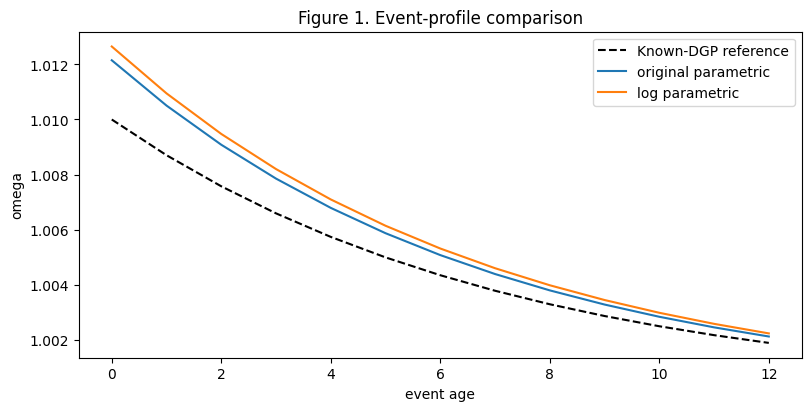

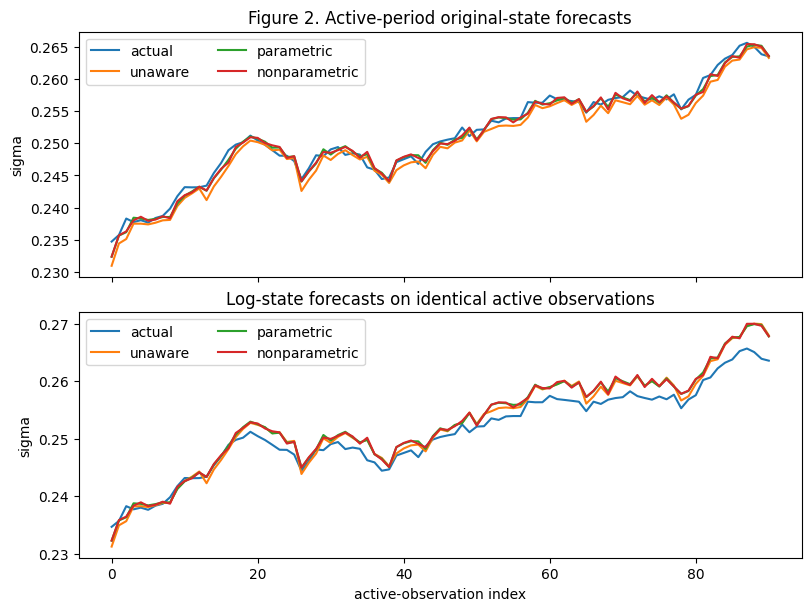

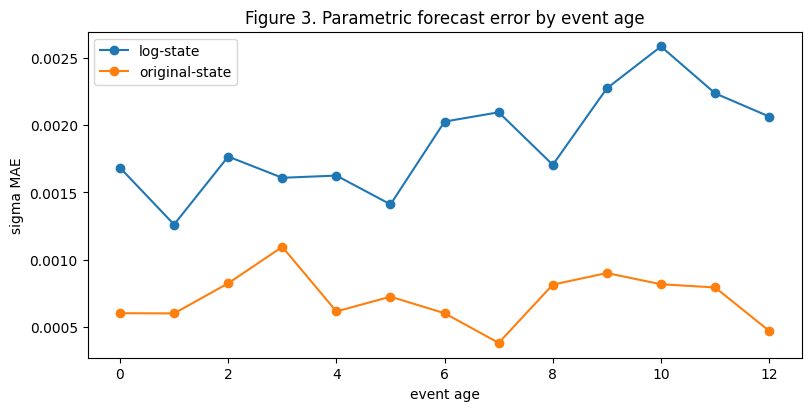

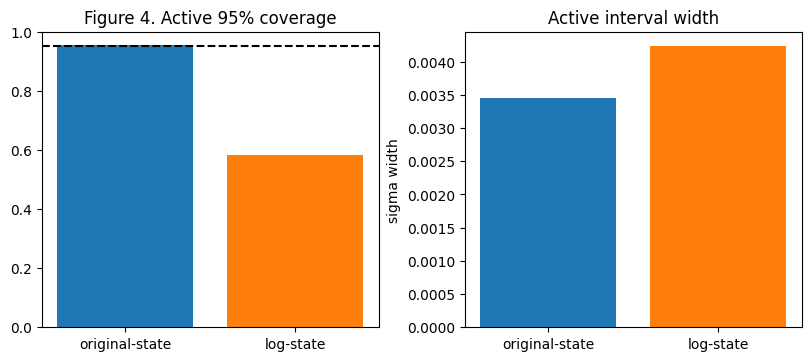

In [4]:
orig_accuracy = original['evaluation']['accuracy']
orig_intervals = original['intervals']['summary']
orig_profiles = original['profiles']
ages = np.arange(13)
truth_omega = profile_table['known_omega'].to_numpy()
orig_param_omega = orig_profiles['parametric_multiplier'](ages) ** 2
orig_np_omega = orig_profiles['nonparametric'].reindex(ages).to_numpy() ** 2

subset_labels = {
    'all': 'overall',
    'active': 'active',
    'event_free': 'event-free',
}
orig_rows = []
for model in log_models:
    for frozen_subset, display_subset in subset_labels.items():
        accuracy_row = orig_accuracy.loc[
            (orig_accuracy['model'].eq(model))
            & (orig_accuracy['evaluation_space'].eq('sigma'))
            & (orig_accuracy['subset'].eq(frozen_subset))
        ].iloc[0]
        interval_row = orig_intervals.loc[
            (orig_intervals['model'].eq(model))
            & (orig_intervals['evaluation_space'].eq('powered_state'))
            & (orig_intervals['subset'].eq(frozen_subset))
            & (orig_intervals['nominal_coverage'].eq(0.95))
        ].iloc[0]
        orig_rows.append({
            'formulation': 'original-state',
            'model': model,
            'subset': display_subset,
            'MAE': accuracy_row['MAE'],
            'RMSE': accuracy_row['RMSE'],
            'coverage': interval_row['empirical_coverage'],
            'average width': interval_row['average_width'],
            'interval score': interval_row['mean_interval_score'],
        })

original_evaluation = pd.DataFrame(orig_rows)
combined_evaluation = pd.concat(
    [original_evaluation, log_evaluation.drop(columns='smearing factor')],
    ignore_index=True,
)[
    ['formulation', 'model', 'subset', 'MAE', 'RMSE', 'coverage', 'average width', 'interval score']
]
combined_evaluation = combined_evaluation.rename(columns={
    'MAE': 'sigma MAE',
    'RMSE': 'sigma RMSE',
    'coverage': '95% coverage',
})
display(combined_evaluation)

orig_eval = original['evaluation']['evaluation']
original_residual_rows = []
common_error_rows = []
for model in log_models:
    error = orig_eval['state_next'] - orig_eval[f'state_forecast_{model}']
    fitted = orig_eval[f'state_forecast_{model}']
    original_residual_rows.append({
        'formulation': 'original-state',
        'model': model,
        'mean': error.mean(),
        'std': error.std(ddof=1),
        'skewness': error.skew(),
        'lag1 autocorrelation': error.autocorr(1),
        'abs residual-fitted correlation': np.corrcoef(np.abs(error), fitted)[0, 1],
    })
    common_error_rows.append({
        'formulation': 'original-state',
        'model': model,
        'sigma MAE': np.abs(error).mean(),
        'sigma RMSE': np.sqrt(np.mean(error ** 2)),
    })

for model in log_models:
    error = test_pred['sigma_next'] - test_pred[f'{model}_sigma']
    common_error_rows.append({
        'formulation': 'log-state',
        'model': model,
        'sigma MAE': np.abs(error).mean(),
        'sigma RMSE': np.sqrt(np.mean(error ** 2)),
    })

original_residual = pd.DataFrame(original_residual_rows)
residual_comparison = pd.concat(
    [original_residual, log_residuals],
    ignore_index=True,
)
common_errors = pd.DataFrame(common_error_rows)
display(residual_comparison)
display(common_errors)

truth_W = np.sqrt(truth_omega)
comparison = pd.DataFrame([
    {
        'formulation': 'original-state',
        'A_hat': orig_profiles['A_hat'],
        'lambda_hat': orig_profiles['lambda_hat'],
        'parametric profile RMSE': np.sqrt(np.mean((orig_param_omega - truth_omega) ** 2)),
        'nonparametric profile RMSE': np.sqrt(np.mean((orig_np_omega - truth_omega) ** 2)),
        'parametric W RMSE': np.sqrt(np.mean((orig_profiles['parametric_multiplier'](ages) - truth_W) ** 2)),
        'nonparametric W RMSE': np.sqrt(np.mean((orig_profiles['nonparametric'].reindex(ages).to_numpy() - truth_W) ** 2)),
    },
    {
        'formulation': 'log-state',
        'A_hat': A_log,
        'lambda_hat': lambda_log,
        'parametric profile RMSE': np.sqrt(np.mean(profile_table['parametric_omega_error'] ** 2)),
        'nonparametric profile RMSE': np.sqrt(np.mean(profile_table['nonparametric_omega_error'] ** 2)),
        'parametric W RMSE': np.sqrt(np.mean((profile_table['parametric_W'] - profile_table['known_W']) ** 2)),
        'nonparametric W RMSE': np.sqrt(np.mean((profile_table['nonparametric_W'] - profile_table['known_W']) ** 2)),
    },
])

for formulation, frame in (
    ('original-state', original_evaluation),
    ('log-state', log_evaluation),
):
    active_parametric = frame.loc[
        frame['model'].eq('parametric') & frame['subset'].eq('active')
    ].iloc[0]
    active_unaware = frame.loc[
        frame['model'].eq('unaware') & frame['subset'].eq('active')
    ].iloc[0]
    row_mask = comparison['formulation'].eq(formulation)
    comparison.loc[row_mask, 'active MAE gain'] = (
        (active_unaware['MAE'] - active_parametric['MAE']) / active_unaware['MAE']
    )
    comparison.loc[row_mask, 'active RMSE gain'] = (
        (active_unaware['RMSE'] - active_parametric['RMSE']) / active_unaware['RMSE']
    )
    comparison.loc[row_mask, '95% coverage error'] = abs(
        active_parametric['coverage'] - 0.95
    )
    comparison.loc[row_mask, 'interval score'] = active_parametric['interval score']
    comparison.loc[row_mask, 'amplitude error'] = (
        comparison.loc[row_mask, 'A_hat'] - dense_case['events']['amplitude']
    )
    comparison.loc[row_mask, 'decay error'] = (
        comparison.loc[row_mask, 'lambda_hat'] - dense_case['events']['decay_rate']
    )

for formulation in comparison['formulation']:
    residual_row = residual_comparison.loc[
        residual_comparison['formulation'].eq(formulation)
        & residual_comparison['model'].eq('parametric')
    ].iloc[0]
    row_mask = comparison['formulation'].eq(formulation)
    comparison.loc[row_mask, 'residual skewness'] = residual_row['skewness']
    comparison.loc[row_mask, 'residual lag1 autocorrelation'] = residual_row['lag1 autocorrelation']

display(comparison)

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.plot(ages, truth_omega, 'k--', label='Known-DGP reference')
ax.plot(ages, orig_param_omega, label='original parametric')
ax.plot(ages, profile_table['parametric_omega'], label='log parametric')
ax.set(
    xlabel='event age',
    ylabel='omega',
    title='Figure 1. Event-profile comparison',
)
ax.legend()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True, constrained_layout=True)
active_log = test_pred['event_active_i'].eq(1)
active_original = orig_eval['event_active_i'].eq(1)
axes[0].plot(orig_eval.loc[active_original, 'sigma_next'].to_numpy(), label='actual')
for model in log_models:
    axes[0].plot(
        orig_eval.loc[active_original, f'sigma_forecast_{model}'].to_numpy(),
        label=model,
    )
axes[0].set(title='Figure 2. Active-period original-state forecasts', ylabel='sigma')
axes[0].legend(ncol=2)
axes[1].plot(test_pred.loc[active_log, 'sigma_next'].to_numpy(), label='actual')
for model in log_models:
    axes[1].plot(test_pred.loc[active_log, f'{model}_sigma'].to_numpy(), label=model)
axes[1].set(
    title='Log-state forecasts on identical active observations',
    xlabel='active-observation index',
    ylabel='sigma',
)
axes[1].legend(ncol=2)
plt.show()

age_errors = []
for formulation, frame in (('original-state', orig_eval), ('log-state', test_pred)):
    for age in ages:
        age_mask = frame['event_age_i'].eq(age)
        forecast_column = (
            'sigma_forecast_parametric'
            if formulation == 'original-state'
            else 'parametric_sigma'
        )
        age_errors.append({
            'formulation': formulation,
            'event age': age,
            'parametric sigma MAE': np.mean(
                np.abs(frame.loc[age_mask, 'sigma_next'] - frame.loc[age_mask, forecast_column])
            ),
        })
age_errors = pd.DataFrame(age_errors)
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for formulation, group in age_errors.groupby('formulation'):
    ax.plot(
        group['event age'],
        group['parametric sigma MAE'],
        marker='o',
        label=formulation,
    )
ax.set(
    title='Figure 3. Parametric forecast error by event age',
    xlabel='event age',
    ylabel='sigma MAE',
)
ax.legend()
plt.show()

interval_plot = combined_evaluation.loc[
    combined_evaluation['model'].eq('parametric')
    & combined_evaluation['subset'].eq('active')
]
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), constrained_layout=True)
for _, row in interval_plot.iterrows():
    axes[0].bar(row['formulation'], row['95% coverage'])
    axes[1].bar(row['formulation'], row['average width'])
axes[0].axhline(0.95, color='k', linestyle='--')
axes[0].set(title='Figure 4. Active 95% coverage', ylim=(0, 1))
axes[1].set(title='Active interval width', ylabel='sigma width')
plt.show()

## Conclusions and next stage

The conclusion is generated from the executed one-seed comparison. A later stage should add paired repeated-seed robustness before any general claim about representation choice.

In [5]:
orig = comparison.loc[comparison['formulation'].eq('original-state')].iloc[0]
log = comparison.loc[comparison['formulation'].eq('log-state')].iloc[0]
wins = {
    'amplitude error': abs(log['amplitude error']) < abs(orig['amplitude error']),
    'decay error': abs(log['decay error']) < abs(orig['decay error']),
    'parametric profile RMSE': log['parametric profile RMSE'] < orig['parametric profile RMSE'],
    'non-parametric profile RMSE': log['nonparametric profile RMSE'] < orig['nonparametric profile RMSE'],
    'active MAE gain': log['active MAE gain'] > orig['active MAE gain'],
    'active RMSE gain': log['active RMSE gain'] > orig['active RMSE gain'],
    'active 95% coverage error': log['95% coverage error'] < orig['95% coverage error'],
    'active interval score': log['interval score'] < orig['interval score'],
    'absolute residual skewness': abs(log['residual skewness']) < abs(orig['residual skewness']),
    'absolute residual lag-1 autocorrelation': (
        abs(log['residual lag1 autocorrelation'])
        < abs(orig['residual lag1 autocorrelation'])
    ),
}
wins_count = sum(wins.values())
metric_count = len(wins)
win_rate = wins_count / metric_count
if win_rate >= 0.70:
    verdict = 'mostly superior'
elif win_rate <= 0.30:
    verdict = 'mostly inferior'
else:
    verdict = 'mixed'

verdict_summary = pd.DataFrame([{
    'log metrics won': wins_count,
    'primary metrics': metric_count,
    'win rate': win_rate,
    'verdict': verdict,
}])
display(verdict_summary)

conclusion = '## Conclusion\n\n'
conclusion += (
    'In this one-seed matched-feature prototype, the log event term is additive '
    'and mathematically interpretable. '
)
conclusion += (
    f"Decay recovery improves slightly (absolute error {abs(log['decay error']):.3f} "
    f"versus {abs(orig['decay error']):.3f}), but amplitude recovery is weaker "
    f"(absolute error {abs(log['amplitude error']):.6f} versus {abs(orig['amplitude error']):.6f}). "
)
conclusion += (
    f"Log/original parametric and non-parametric profile RMSEs are "
    f"{log['parametric profile RMSE']:.6f}/{orig['parametric profile RMSE']:.6f} and "
    f"{log['nonparametric profile RMSE']:.6f}/{orig['nonparametric profile RMSE']:.6f}. "
)
conclusion += (
    f"Event-aware log forecasts have negative active-period gains "
    f"({log['active MAE gain']:.1%} MAE and {log['active RMSE gain']:.1%} RMSE), "
    f"whereas the original-state gains are {orig['active MAE gain']:.1%} and "
    f"{orig['active RMSE gain']:.1%}. "
)
conclusion += (
    f"Log residual lag-1 autocorrelation is substantially greater "
    f"({log['residual lag1 autocorrelation']:.3f} versus "
    f"{orig['residual lag1 autocorrelation']:.3f}), and log prediction intervals are "
    f"poorly calibrated (active 95% coverage error {log['95% coverage error']:.3f} "
    f"versus {orig['95% coverage error']:.3f}). "
)
conclusion += (
    f"The log formulation wins {wins_count} of {metric_count} primary comparisons "
    f"and is therefore {verdict} under the retained raw linear predictor basis. "
    'This may reflect nonlinear background-baseline misspecification rather than a failure '
    'of the additive event decomposition itself. Smearing remains a training-estimated '
    'back-transformation adjustment, while empirical log-residual interval endpoints do not use it. '
    'Repeated-seed evidence is required before any general conclusion. Known-DGP values were used only after fitting for evaluation.'
)
display(Markdown(conclusion))
assert np.isfinite(
    log_evaluation[['MAE', 'RMSE', 'coverage', 'interval score', 'smearing factor']]
).all().all()

,log metrics won,primary metrics,win rate,verdict
0,1,10,0.1,mostly inferior


## Conclusion

In this one-seed matched-feature prototype, the log event term is additive and mathematically interpretable. Decay recovery improves slightly (absolute error 1.415 versus 1.653), but amplitude recovery is weaker (absolute error 0.002651 versus 0.002151). Log/original parametric and non-parametric profile RMSEs are 0.001370/0.001081 and 0.002145/0.001954. Event-aware log forecasts have negative active-period gains (-8.2% MAE and -5.5% RMSE), whereas the original-state gains are 37.6% and 34.9%. Log residual lag-1 autocorrelation is substantially greater (0.425 versus -0.117), and log prediction intervals are poorly calibrated (active 95% coverage error 0.368 versus 0.006). The log formulation wins 1 of 10 primary comparisons and is therefore mostly inferior under the retained raw linear predictor basis. This may reflect nonlinear background-baseline misspecification rather than a failure of the additive event decomposition itself. Smearing remains a training-estimated back-transformation adjustment, while empirical log-residual interval endpoints do not use it. Repeated-seed evidence is required before any general conclusion. Known-DGP values were used only after fitting for evaluation.

Next stage: paired repeated-seed robustness of the original-state and log-state comparison, retaining the same information set and post-fit Known-DGP evaluation boundary.